In [13]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors


import os
import scanpy as sc
import scvi
import seaborn as sns



## Load Data

In [14]:
# Save dataframe 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris
atac_bc,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO


In [15]:
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
h5_rna_union_file = os.path.join(Union_cell_subdir, 'Union_3set_rna.h5ad')

h5_rna_union = sc.read_h5ad(h5_rna_union_file)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [16]:
h5_rna_union, h5_rna_union.shape

(AnnData object with n_obs × n_vars = 2381 × 36601
     obs: 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'gene_ids', 'feature_types', 'genome',
 (2381, 36601))

In [17]:
sc.pp.filter_genes(h5_rna_union, min_counts=3)
h5_rna_union.raw = h5_rna_union # keep full dimension safe
h5_rna_union.layers['counts'] = h5_rna_union.X
sc.pp.highly_variable_genes(
h5_rna_union    ,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [18]:
SCVI_LATENT_KEY = "RNA_scVI_unionBC"
SCVI_CLUSTERS_KEY = "leiden_RNA_scVI_unionBC"


vae_model_folder=os.path.join(entropy_dir, "_unioncells_RNA_scvi_model")
vae =scvi.model.SCVI.load(vae_model_folder, adata=h5_rna_union)
h5_rna_union.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()
sc.pp.neighbors(h5_rna_union, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna_union, min_dist=0.3)


# clustering using scVI latent representation via Leiden
atac_resolution = 0.5
sc.pp.neighbors(h5_rna_union, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna_union, min_dist=0.3)
sc.tl.leiden(h5_rna_union, key_added=SCVI_CLUSTERS_KEY, resolution=atac_resolution + 0.1)

INFO     File /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_unioncells_RNA_scvi_model/model.pt      
         already downloaded                                                                                        


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

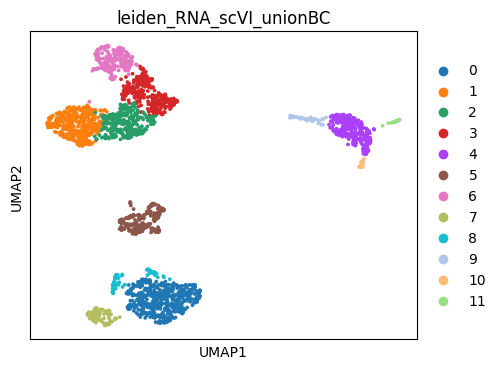

In [19]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_union, color=['leiden_RNA_scVI_unionBC'], wspace=0.2, size=30, ncols=3)

In [20]:
col_list = ['total_fragments', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_entropy',
       'atac_pass_archr_TSS', '_2set_identified_by_atac_SC',
       '_2set_identified_by_atac_ST', 'rna_barcodes', 'rna_pass_CR', 'Entropy', 'DNA_debris']
for col in col_list:
    h5_rna_union.obs[col] = h5_rna_union.obs['atac_barcodes'].map(union_cell_info[col])

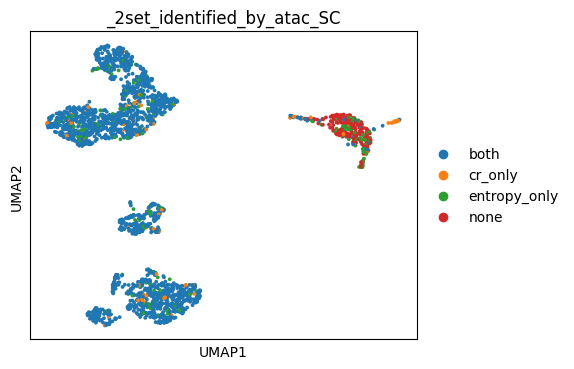

In [21]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_union, color=['_2set_identified_by_atac_SC'], wspace=0.2, size=30, ncols=3)

# See union BCs clustering using Entropy peaks 

In [32]:
entropy_peak_dir = os.path.join(Union_cell_subdir, "Entropy_cells_peaks")
atac_entropy_peak_pic = os.path.join(entropy_peak_dir, "DownstreamReanalysis", "bc_peak_pic_count.h5ad" )
h5_atac_entropy_peak = sc.read_h5ad(atac_entropy_peak_pic)
h5_atac_entropy_peak.obs['atac_barcodes'] = h5_atac_entropy_peak.obs['barcodes'].map(lambda x: x.split("-")[0])


In [33]:

col_list = ['total_fragments', 'atac_pass_CR', 'atac_pass_entropy',
       'atac_pass_archr_TSS', '_2set_identified_by_atac_SC',
       '_2set_identified_by_atac_ST', 'rna_barcodes', 'rna_pass_CR', 'Entropy', 'DNA_debris']
for col in col_list:
    h5_atac_entropy_peak.obs[col] = h5_atac_entropy_peak.obs['atac_barcodes'].map(union_cell_info[col])
    
h5_atac_entropy_peak.obs['log10_total_frag'] = np.log10(h5_atac_entropy_peak.obs['total_fragments'])


In [34]:

scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

# %%
PEAKVI_LATENT_KEY = "X_peakvi_SADEpeaks_unionBC"
PEAKVI_CLUSTERS_KEY = "clusters_peakvi_Entropypeaks_unionBC"

#%%
# # filter regions with less than 3% of the cells
print("# regions before filtering:", h5_atac_entropy_peak.shape[-1])

sc.pp.filter_genes(h5_atac_entropy_peak, min_cells=10)
print("# regions after filtering:", h5_atac_entropy_peak.shape[-1])

# Let's Use All the identified peaks for comarison (since entropy approach already has more peaks)
# train on h5_atac_entropy_peak
scvi.model.PEAKVI.setup_anndata(h5_atac_entropy_peak)
peak_model = scvi.model.PEAKVI(h5_atac_entropy_peak)
peak_model.train()
# #save model
# peak_model.save(des_model_dir, overwrite=True)

# #save latent representation back adata
latent = peak_model.get_latent_representation()
h5_atac_entropy_peak.obsm[PEAKVI_LATENT_KEY] = latent
resolution = 0.5
sc.pp.neighbors(h5_atac_entropy_peak, use_rep=PEAKVI_LATENT_KEY)
sc.tl.umap(h5_atac_entropy_peak, min_dist=0.5)
sc.tl.leiden(h5_atac_entropy_peak, key_added=PEAKVI_CLUSTERS_KEY, resolution=resolution)

Seed set to 0
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


Last run with scvi-tools version: 1.2.0
# regions before filtering: 62565
# regions after filtering: 61526


/tmp/ipykernel_3700015/1354445141.py:19: DeprecationWarning: `save_best` is deprecated in v1.2 and will be removed in v1.3. Please use `enable_checkpointing` instead. See https://github.com/scverse/scvi-tools/issues/2568 for more details.
  peak_model.train()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers

Epoch 81/500:  16%|█▌        | 81/500 [00:48<04:11,  1.66it/s, v_num=1, train_loss_step=9.83e+7, train_loss_epoch=1.63e+8]
Monitored metric reconstruction_loss_validation did not improve in the last 50 records. Best score: 11755.613. Signaling Trainer to stop.


In [35]:
rna_col_list = ['MT%', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'leiden_RNA_scVI_unionBC', 'DNA_debris']
for col in rna_col_list:
    h5_atac_entropy_peak.obs[col] = h5_atac_entropy_peak.obs['atac_barcodes'].map(h5_rna_union.obs.set_index('atac_barcodes')[col])
h5_atac_entropy_peak.obs['leiden_RNA_scVI_unionBC'] = h5_atac_entropy_peak.obs['leiden_RNA_scVI_unionBC'].cat.add_categories('noRNAinfo')
h5_atac_entropy_peak.obs['leiden_RNA_scVI_unionBC'] = h5_atac_entropy_peak.obs['leiden_RNA_scVI_unionBC'].fillna('noRNAinfo', inplace=False)

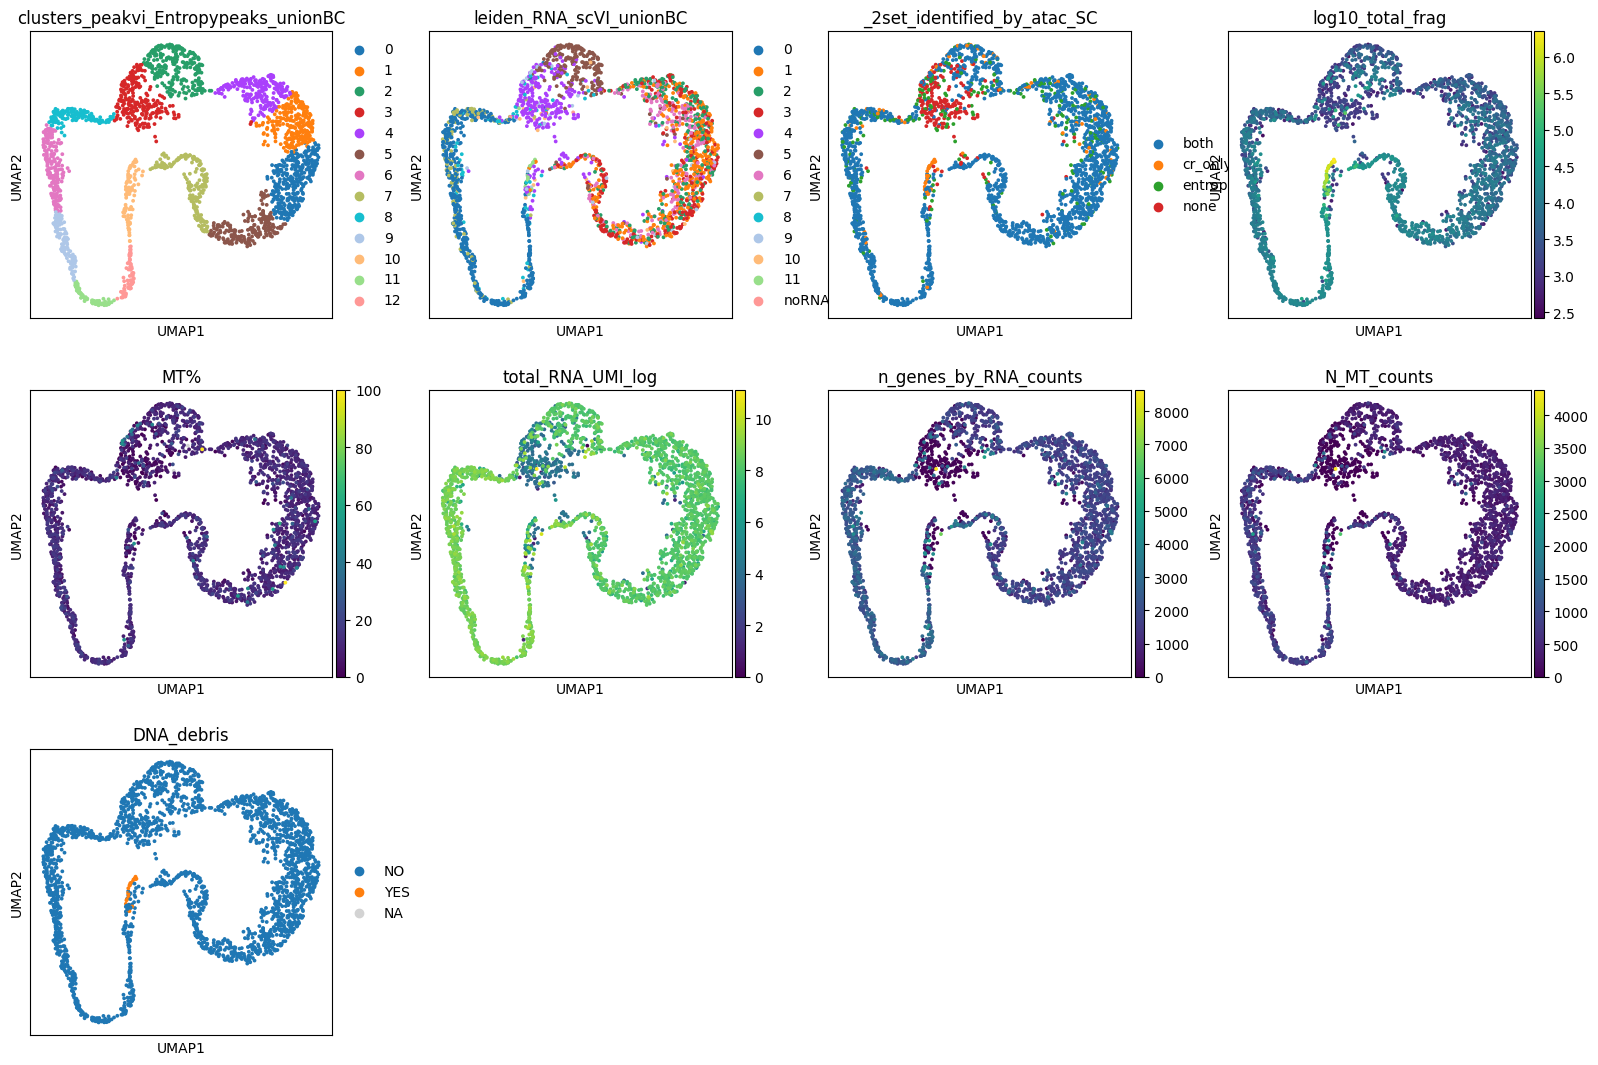

In [36]:

with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(h5_atac_entropy_peak, color=['clusters_peakvi_Entropypeaks_unionBC', ] + 
               ['leiden_RNA_scVI_unionBC', ] + ['_2set_identified_by_atac_SC'] + 
               ['log10_total_frag'] +
               ['MT%', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'DNA_debris' ], wspace=0.2, size=30, ncols=4)

In [37]:
# Save results
# Bad cluster c3, c10 
# c10 -- high DNA debris, 
# c3 -- low total_frag, 

h5_atac_entropy_peak.obs['good_cluster'] = ~h5_atac_entropy_peak.obs['clusters_peakvi_Entropypeaks_unionBC'].isin(['3', '10'])

h5_atac_entropy_peak.obs.to_csv(os.path.join(Union_cell_subdir, "Entropy_cells_peaks", "DownstreamReanalysis", "union_3set_Entropypeaks_cluster.tsv"), sep='\t', index=False)


In [38]:
h5_atac_entropy_peak.obs.groupby(['good_cluster', 'atac_pass_entropy']).size().unstack(fill_value=0)

atac_pass_entropy,False,True
good_cluster,,
False,180,155
True,103,1946


In [39]:
h5_atac_entropy_peak.obs.groupby(['good_cluster', 'atac_pass_archr_TSS']).size().unstack(fill_value=0)

atac_pass_archr_TSS,False,True
good_cluster,,
False,95,240
True,157,1892


In [40]:
h5_atac_entropy_peak.obs.groupby(['good_cluster', 'atac_pass_CR']).size().unstack(fill_value=0)

atac_pass_CR,False,True
good_cluster,,
False,207,128
True,218,1831


## How many cells do not have enough ATAC features 

In [50]:
Nfeatures = 200 
h5_atac_entropy_peak.obs['enough_entropy_peaks_features'] = (h5_atac_entropy_peak.X > 0).sum(axis=1) > Nfeatures

In [51]:
h5_atac_entropy_peak.obs.groupby(['enough_entropy_peaks_features', 'atac_pass_CR']).size().unstack(fill_value=0)

atac_pass_CR,False,True
enough_entropy_peaks_features,,
False,253,0
True,172,1959


In [52]:
h5_atac_entropy_peak.obs.groupby(['enough_entropy_peaks_features', 'atac_pass_entropy']).size().unstack()

atac_pass_entropy,False,True
enough_entropy_peaks_features,,
False,188,65
True,95,2036


In [53]:
h5_atac_entropy_peak.obs.groupby(['enough_entropy_peaks_features', 'atac_pass_archr_TSS']).size().unstack()

atac_pass_archr_TSS,False,True
enough_entropy_peaks_features,,
False,59,194
True,193,1938


## consistency on RNA space

In [ ]:
h5_atac_entropy_peak.obs.groupby(['clusters_peakvi_Entropypeaks_unionBC', ] + 
               ['leiden_RNA_scVI_unionBC', ] ).size().unstack(fill_value=0)

/tmp/ipykernel_2593055/1947509521.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_atac_entropy_peak.obs.groupby(['clusters_peakvi_SADEpeaks_unionBC', ] +


leiden_RNA_scVI_unionBC,0,1,2,3,4,5,6,7,8,9,10,11,noRNAinfo
clusters_peakvi_SADEpeaks_unionBC,,,,,,,,,,,,,
0,0,127,68,76,3,1,47,0,0,9,1,0,0
1,0,71,68,45,5,5,57,0,1,1,2,0,0
2,2,0,2,2,36,194,1,0,6,2,3,0,0
3,4,1,2,0,166,13,1,3,17,20,9,1,2
4,0,44,76,36,2,5,48,1,0,1,0,0,0
5,0,67,42,56,4,1,32,0,0,4,2,0,0
6,152,0,0,0,1,0,0,38,11,1,0,0,0
7,0,49,30,63,15,5,23,0,1,2,1,0,0
8,95,0,0,0,4,0,0,39,8,0,1,0,1


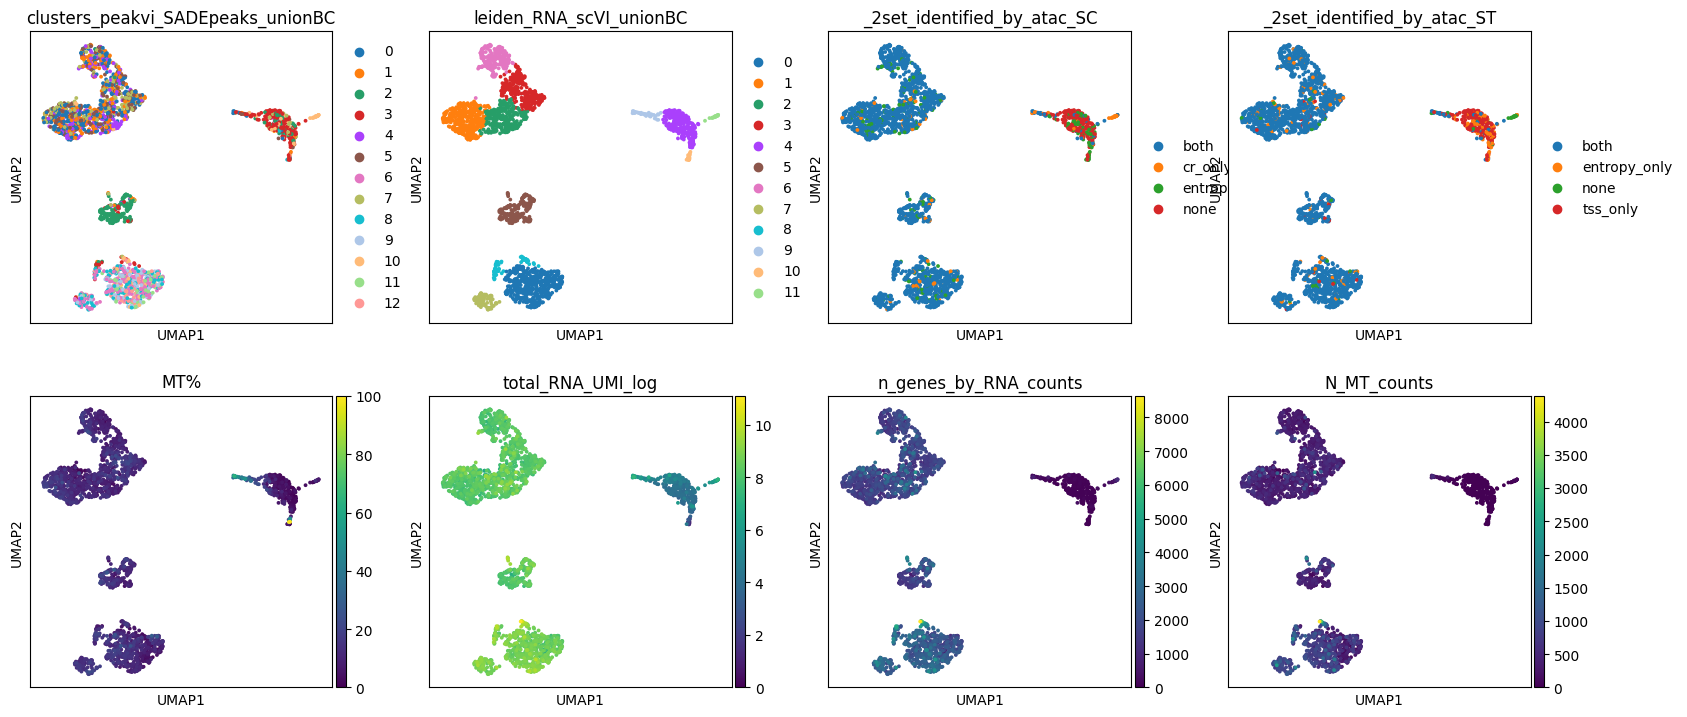

In [ ]:
h5_rna_union.obs['clusters_peakvi_Entropypeaks_unionBC'] = h5_rna_union.obs['atac_barcodes'].map(h5_atac_entropy_peak.obs.set_index('atac_barcodes')['clusters_peakvi_Entropypeaks_unionBC'])

with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(h5_rna_union, color=['clusters_peakvi_Entropypeaks_unionBC', ] + 
               ['leiden_RNA_scVI_unionBC', ] + ['_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST'] + 
               ['MT%', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', ], wspace=0.2, size=30, ncols=4)

## Check AMULET doublet 

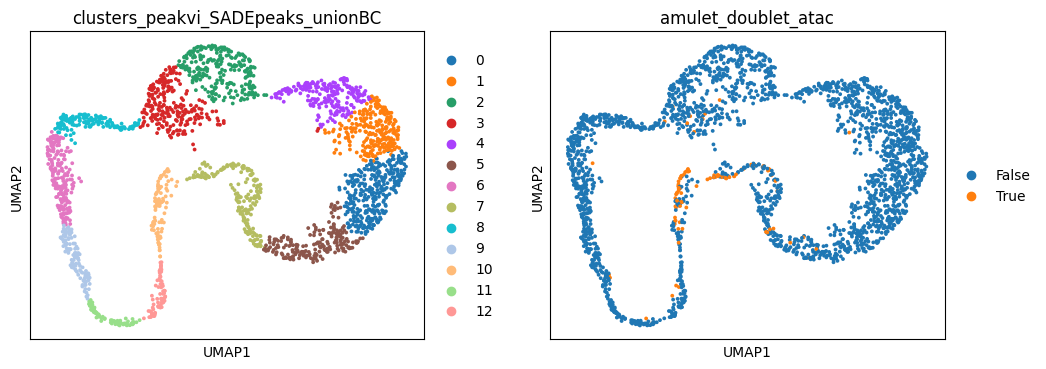

In [ ]:
amulet_doublet_atac_file = os.path.join(Union_cell_subdir, 'AMULET_output/MultipletBarcodes_01.txt')
doublet_atac_barcodes = pd.read_csv(amulet_doublet_atac_file, header=None)
doublet_atac_barcodes.columns = ['barcodes']
doublet_atac_barcodes['atac_bc'] = doublet_atac_barcodes['barcodes'].str.split('-').str[0]
doublet_atac_barcodes.head(2)


h5_atac_entropy_peak.obs['amulet_doublet_atac'] = h5_atac_entropy_peak.obs['atac_barcodes'].isin(doublet_atac_barcodes['atac_bc'])

with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_atac_entropy_peak, color=['clusters_peakvi_Entropypeaks_unionBC', 'amulet_doublet_atac'], wspace=0.2, size=30, ncols=2)

# SADE BCs set on ATAC space

In [54]:
h5_atac_entropy_peak_SADE = h5_atac_entropy_peak[h5_atac_entropy_peak.obs['atac_pass_entropy']].copy()

h5_atac_entropy_peak_SADE.shape

(2101, 61526)

In [55]:

scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

# %%
PEAKVI_LATENT_KEY = "X_peakvi_SADEpeaks_entropyBC"
PEAKVI_CLUSTERS_KEY = "clusters_peakvi_SADEpeaks_entropyBC"

#%%
# # filter regions with less than 3% of the cells
print("# regions before filtering:", h5_atac_entropy_peak_SADE.shape[-1])

sc.pp.filter_genes(h5_atac_entropy_peak_SADE, min_cells=10)
print("# regions after filtering:", h5_atac_entropy_peak_SADE.shape[-1])

# Let's Use All the identified peaks for comarison (since entropy approach already has more peaks)
# train on h5_atac_entropy_peak_SADE
scvi.model.PEAKVI.setup_anndata(h5_atac_entropy_peak_SADE)
peak_model = scvi.model.PEAKVI(h5_atac_entropy_peak_SADE)
peak_model.train()
# #save model
# peak_model.save(des_model_dir, overwrite=True)

# #save latent representation back adata
latent = peak_model.get_latent_representation()
h5_atac_entropy_peak_SADE.obsm[PEAKVI_LATENT_KEY] = latent
resolution = 0.5
sc.pp.neighbors(h5_atac_entropy_peak_SADE, use_rep=PEAKVI_LATENT_KEY)
sc.tl.umap(h5_atac_entropy_peak_SADE, min_dist=0.5)
sc.tl.leiden(h5_atac_entropy_peak_SADE, key_added=PEAKVI_CLUSTERS_KEY, resolution=resolution)

Seed set to 0
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


Last run with scvi-tools version: 1.2.0
# regions before filtering: 61526
# regions after filtering: 61448


/tmp/ipykernel_2593055/612785117.py:19: DeprecationWarning: `save_best` is deprecated in v1.2 and will be removed in v1.3. Please use `enable_checkpointing` instead. See https://github.com/scverse/scvi-tools/issues/2568 for more details.
  peak_model.train()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers`

Epoch 222/500:  44%|████▍     | 222/500 [01:55<02:24,  1.93it/s, v_num=1, train_loss_step=1.07e+8, train_loss_epoch=1.68e+8]
Monitored metric reconstruction_loss_validation did not improve in the last 50 records. Best score: 12619.614. Signaling Trainer to stop.


Epoch 148/500:  29%|██▉       | 147/500 [06:49<16:22,  2.78s/it, v_num=1, train_loss_step=1.1e+8, train_loss_epoch=1.72e+8]


/tmp/ipykernel_2593055/3777711362.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


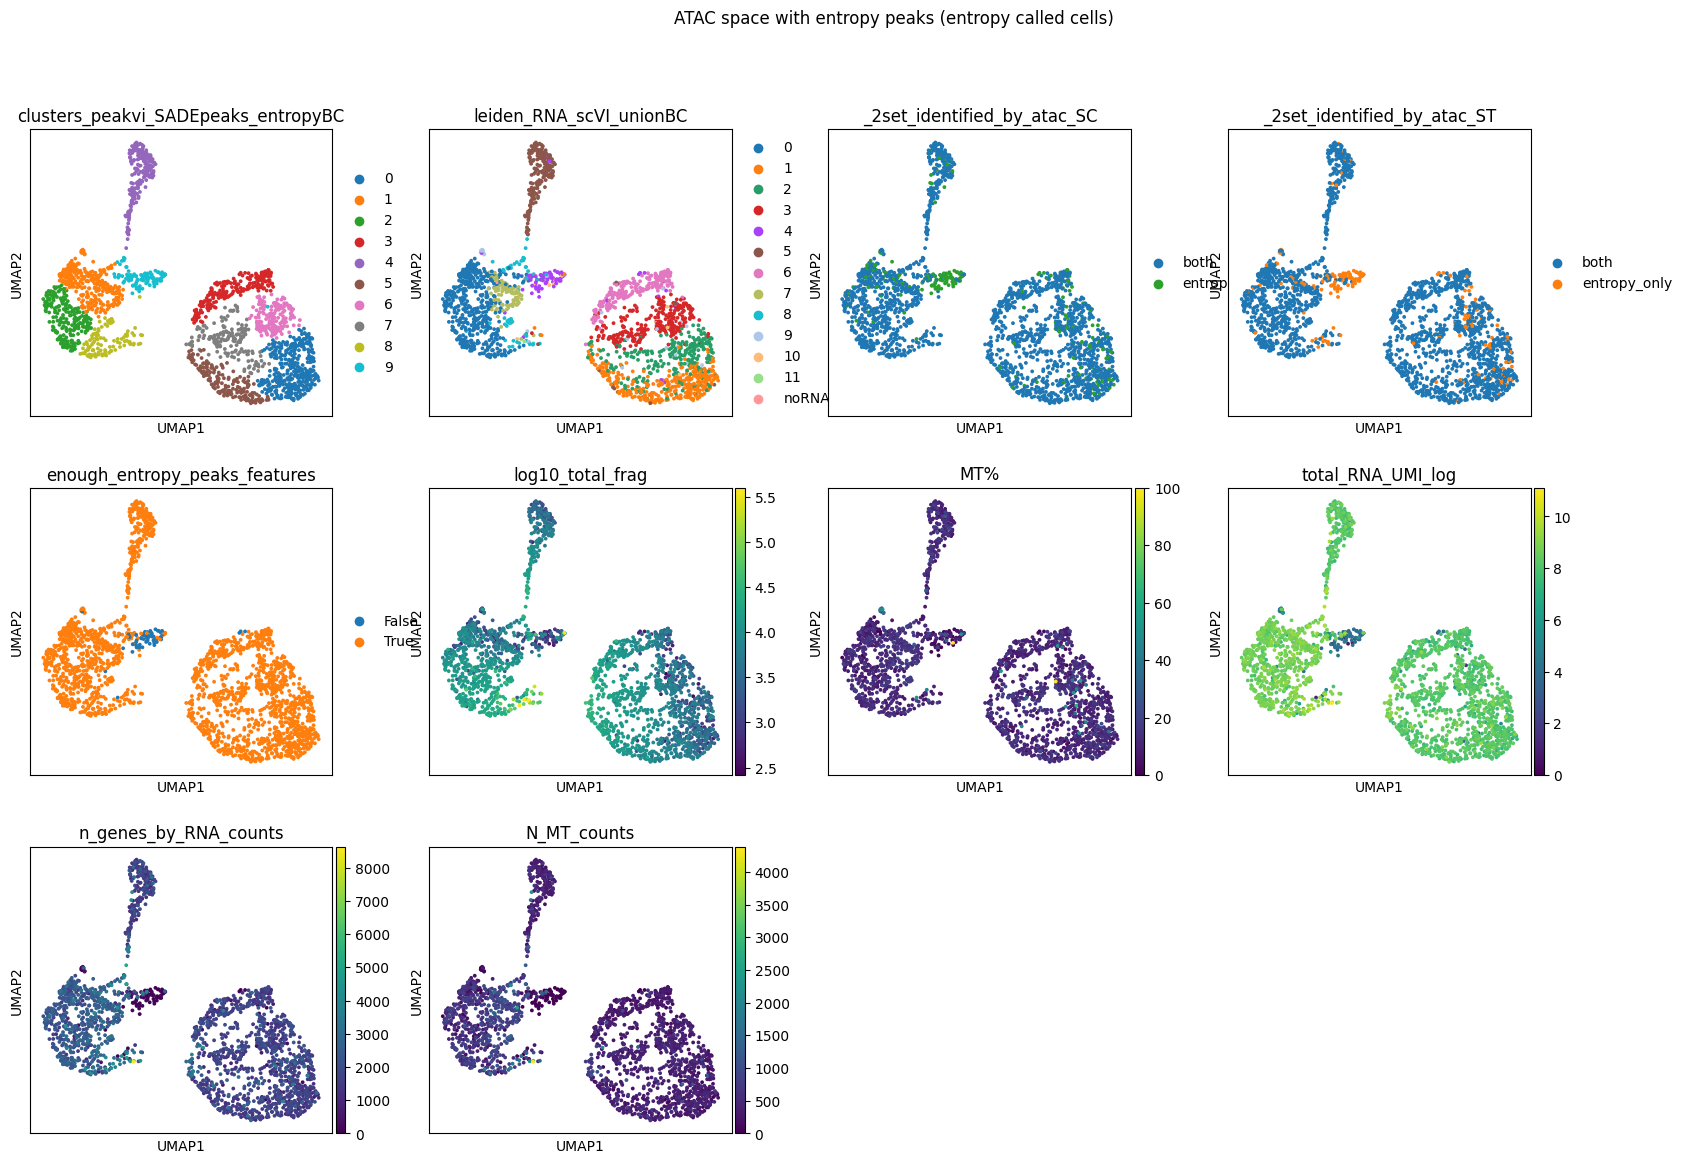

In [56]:

with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(h5_atac_entropy_peak_SADE, color=['clusters_peakvi_SADEpeaks_entropyBC', ] + 
               ['leiden_RNA_scVI_unionBC', ] + ['_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST'] + 
               ['enough_entropy_peaks_features'] + 
               ['log10_total_frag'] +
               ['MT%', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', ], wspace=0.2, size=30, ncols=4, show=False)
    
    plt.suptitle("ATAC space with entropy peaks (entropy called cells)")
    plt.tight_layout()

In [ ]:
## 
SADE_atac_cluster_info_subdir = os.path.join(Union_cell_subdir, "SADE_atac_cluster_info")
SADE_atac_cluster_info_file = os.path.join(SADE_atac_cluster_info_subdir, "SADE_atac_cluster_info.tsv")

if not os.path.exists(SADE_atac_cluster_info_subdir):
    os.makedirs(SADE_atac_cluster_info_subdir)

h5_atac_entropy_peak_SADE.obs.to_csv(SADE_atac_cluster_info_file, sep='\t', index=False)

## Check DARS

In [53]:
atac_cluster_DARs = {}
cluster_list = h5_atac_entropy_peak_SADE.obs['clusters_peakvi_SADE'].unique()
for cluster in cluster_list:
    print(f" DARs on atac-cluster {cluster}")
    atac_cluster_DARs[cluster] = peak_model.differential_accessibility(
        groupby="clusters_peakvi_SADE", group1=cluster,  two_sided=True
    )

 DARs on atac-cluster 6
DE...: 100%|██████████| 1/1 [00:48<00:00, 48.53s/it]
 DARs on atac-cluster 9
DE...: 100%|██████████| 1/1 [00:45<00:00, 45.75s/it]
 DARs on atac-cluster 4
DE...: 100%|██████████| 1/1 [00:42<00:00, 42.13s/it]
 DARs on atac-cluster 1
DE...: 100%|██████████| 1/1 [00:24<00:00, 24.01s/it]
 DARs on atac-cluster 2
DE...: 100%|██████████| 1/1 [00:09<00:00,  9.86s/it]
 DARs on atac-cluster 8
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.13s/it]
 DARs on atac-cluster 0
DE...: 100%|██████████| 1/1 [00:06<00:00,  6.91s/it]
 DARs on atac-cluster 5
DE...: 100%|██████████| 1/1 [00:06<00:00,  6.95s/it]
 DARs on atac-cluster 7
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.08s/it]
 DARs on atac-cluster 3
DE...: 100%|██████████| 1/1 [00:07<00:00,  7.01s/it]


In [55]:
## manually change effect-size sign 
for cluster in atac_cluster_DARs.keys():
    atac_cluster_DARs[cluster]['effect_size_correct_sign'] = -atac_cluster_DARs[cluster]['effect_size']


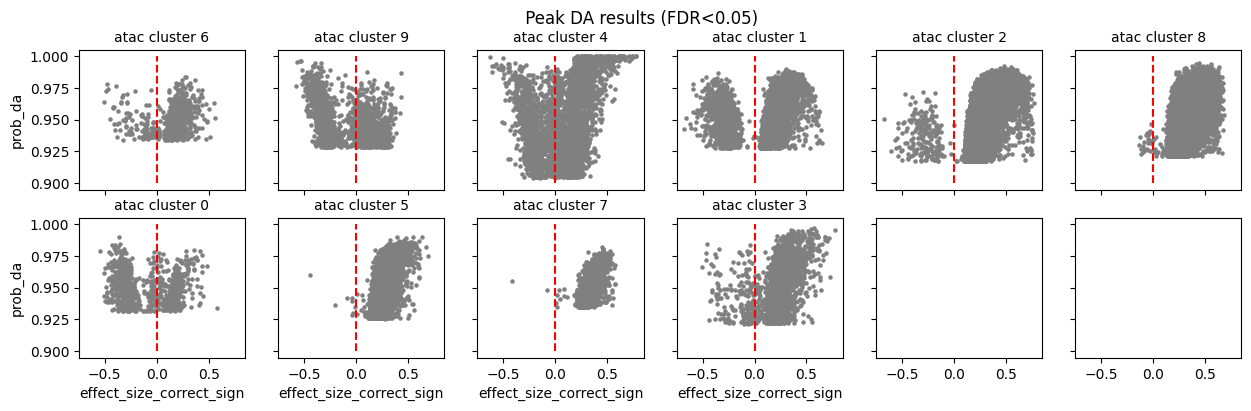

In [56]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) ].plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 5, c='grey' )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(' Peak DA results (FDR<0.05) ', fontsize=12)
plt.show()

## Check Peaks

In [57]:
peaks_columns_set = ['chrom', 'chromStart', 'chromEnd', 'peak_name', 'peak_auc_score', 'strand', 'signalValue', 'pValue', 'qValue', 'peak']
cCREs_annot_columns_set = ['cCREs' + col for col in ['chr', 'Start', 'End', 'name', 'name2', 'category', 'overlap_bp']]

cCRES_annot_entropy_peak_file = os.path.join(entropy_peak_dir, "cCRE_annotation", 'cCRE_annot_peaks.bed')
cCRES_annot_entropy_peak = pd.read_csv(cCRES_annot_entropy_peak_file, sep='\t', header=None)

cCRES_annot_entropy_peak.columns = peaks_columns_set + cCREs_annot_columns_set
cCRES_annot_entropy_peak['peak_pos'] = cCRES_annot_entropy_peak['chrom'] + ":" + cCRES_annot_entropy_peak['chromStart'].astype(str) + "-" + cCRES_annot_entropy_peak['chromEnd'].astype(str)

In [58]:
cCRES_annot = cCRES_annot_entropy_peak.loc[cCRES_annot_entropy_peak['cCREsoverlap_bp'] > 0].copy()

print("Number of peaks ", cCRES_annot_entropy_peak.shape[0])
print("Number of peaks overlapping cCREs ", cCRES_annot.shape[0])

Number of peaks  146808
Number of peaks overlapping cCREs  144660


In [59]:
# annotate the peaks with cCREs annotation
for cluster in atac_cluster_DARs.keys():
    atac_cluster_DARs[cluster]['peak_pos'] = h5_atac_entropy_peak_SADE.var['peak'].loc[atac_cluster_DARs[cluster].index]
    
    
cCREs_catogories = cCRES_annot['cCREscategory'].unique()
print("unique cCREs_catogories: ", cCREs_catogories)

for cat in cCREs_catogories:
    print(f"Annotating peaks with cCRE category {cat}")
    for cluster in atac_cluster_DARs.keys():
        atac_cluster_DARs[cluster][f'overlap_{cat}'] = atac_cluster_DARs[cluster]['peak_pos'].isin(cCRES_annot.loc[cCRES_annot['cCREscategory'] == cat, 'peak_pos'])

unique cCREs_catogories:  ['PLS' 'pELS,CTCF-bound' 'PLS,CTCF-bound' 'dELS'
 'DNase-H3K4me3,CTCF-bound' 'dELS,CTCF-bound' 'pELS'
 'CTCF-only,CTCF-bound' 'DNase-H3K4me3']
Annotating peaks with cCRE category PLS
Annotating peaks with cCRE category pELS,CTCF-bound
Annotating peaks with cCRE category PLS,CTCF-bound
Annotating peaks with cCRE category dELS
Annotating peaks with cCRE category DNase-H3K4me3,CTCF-bound
Annotating peaks with cCRE category dELS,CTCF-bound
Annotating peaks with cCRE category pELS
Annotating peaks with cCRE category CTCF-only,CTCF-bound
Annotating peaks with cCRE category DNase-H3K4me3


## Plot DARs in cCRE categories

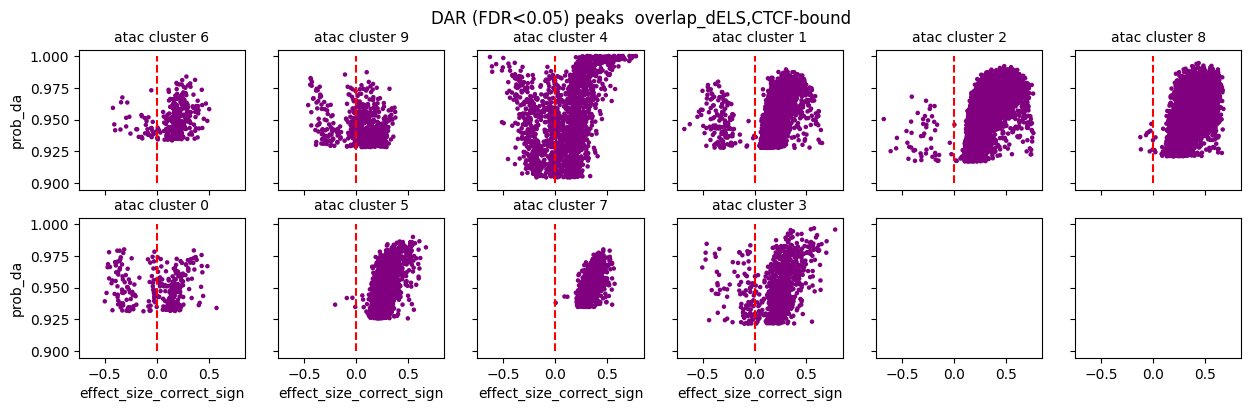

In [60]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'purple', False: 'grey'}
show_cat = 'overlap_' + 'dELS,CTCF-bound'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 5, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

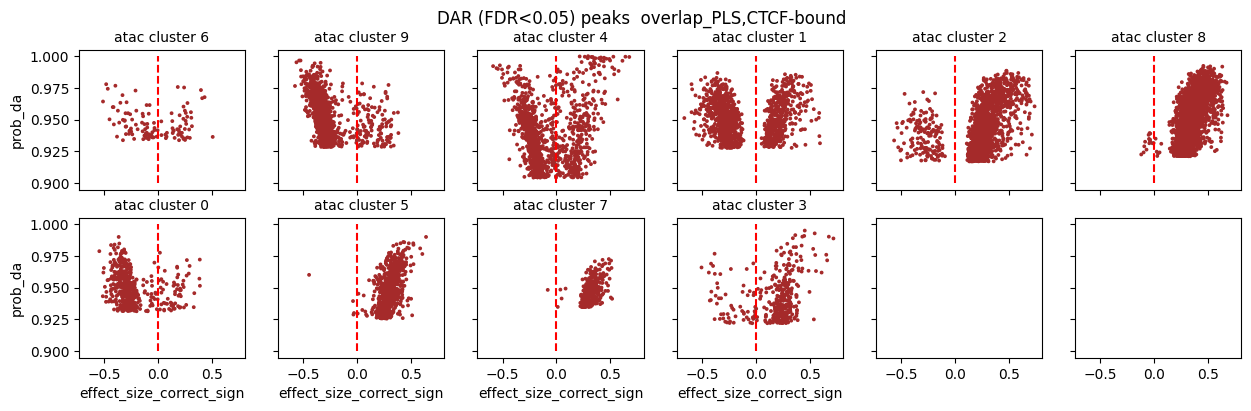

In [61]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'brown', False: 'grey'}
show_cat = 'overlap_' + 'PLS,CTCF-bound'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 3, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

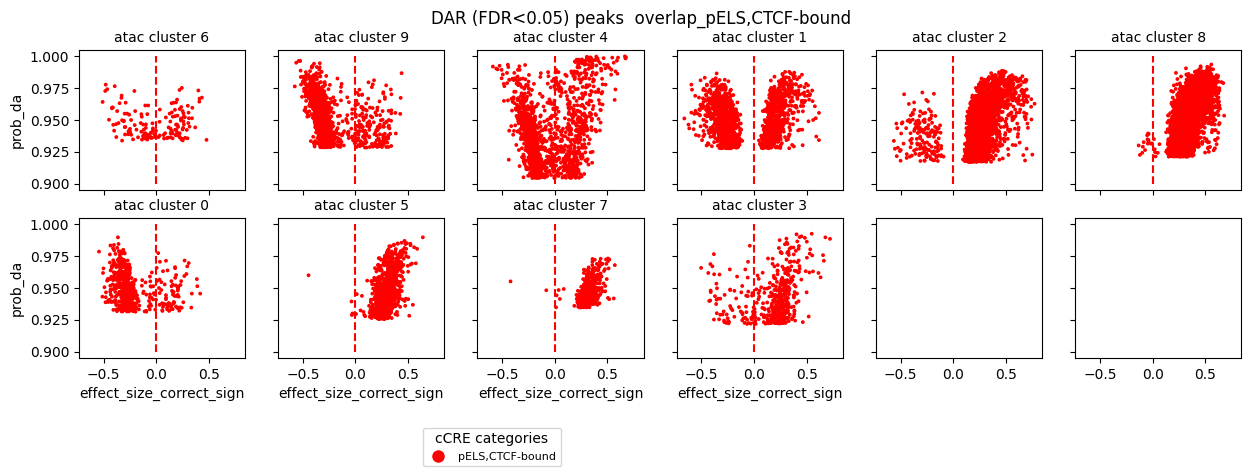

In [62]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'red', False: 'grey'}
show_cat = 'overlap_' + 'pELS,CTCF-bound'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 3, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='pELS,CTCF-bound')]
fig.legend(handles=handles, loc='upper right', title='cCRE categories', fontsize=8, bbox_to_anchor=(0.45, -0.05))
plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

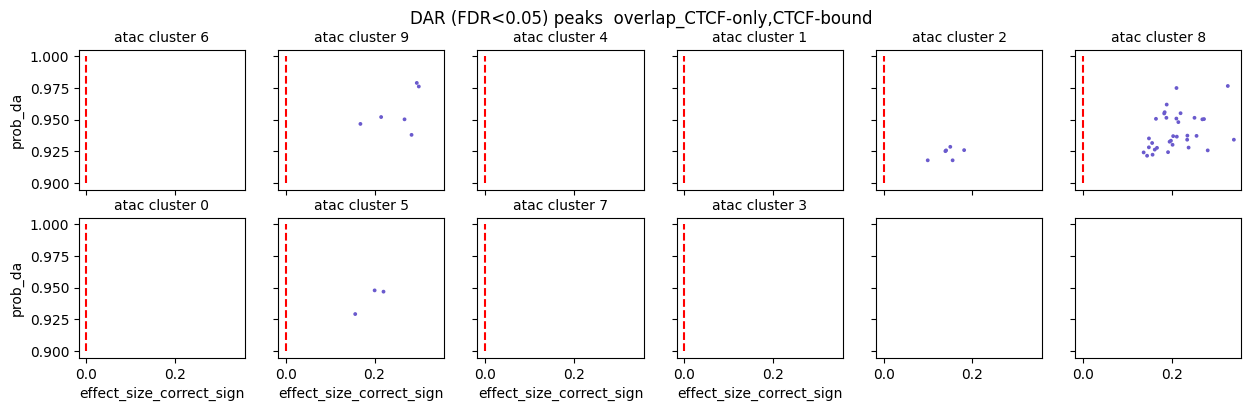

In [63]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'slateblue', False: 'grey'}
show_cat = 'overlap_' + 'CTCF-only,CTCF-bound'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 3, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

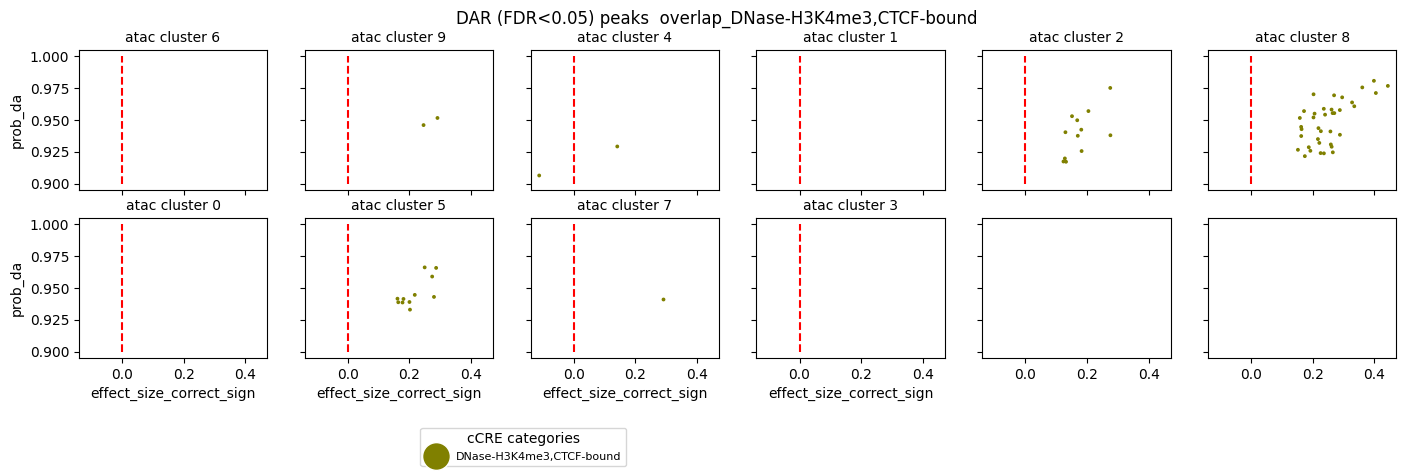

In [64]:
fig, axes = plt.subplots(2, 6,  figsize=(17,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'olive', False: 'grey'}
show_cat = 'overlap_' + 'DNase-H3K4me3,CTCF-bound'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 3, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

# add a single legend for the whole figure

handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='olive', markersize=20, label='DNase-H3K4me3,CTCF-bound')]
fig.legend(handles=handles, loc='upper right', title='cCRE categories', fontsize=8, bbox_to_anchor=(0.45, -0.05))

plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

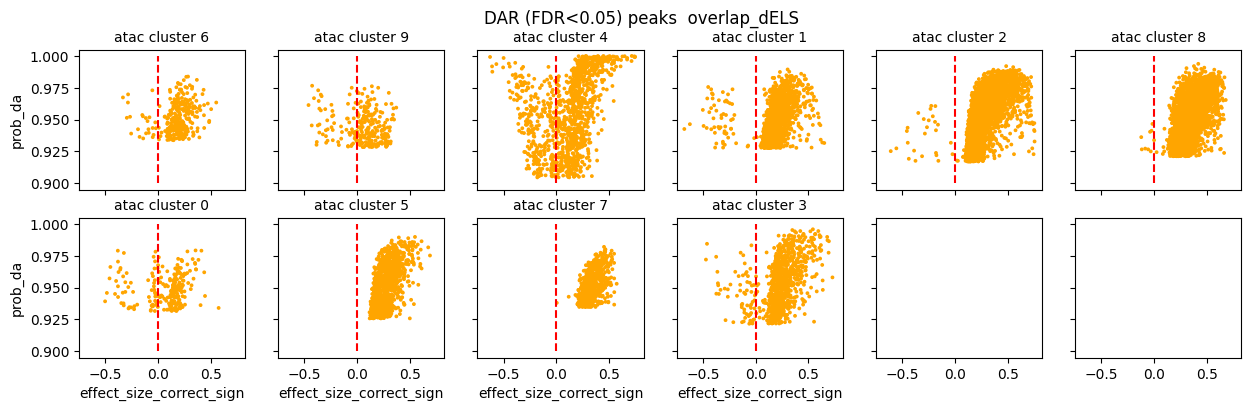

In [65]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'orange', False: 'grey'}
show_cat = 'overlap_' + 'dELS'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 3, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

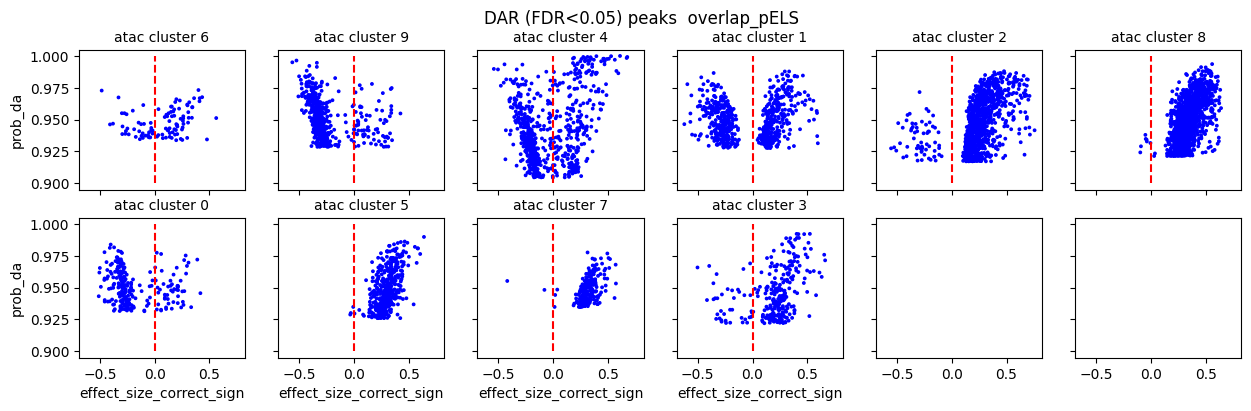

In [66]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'blue', False: 'grey'}
show_cat = 'overlap_' + 'pELS'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 3, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

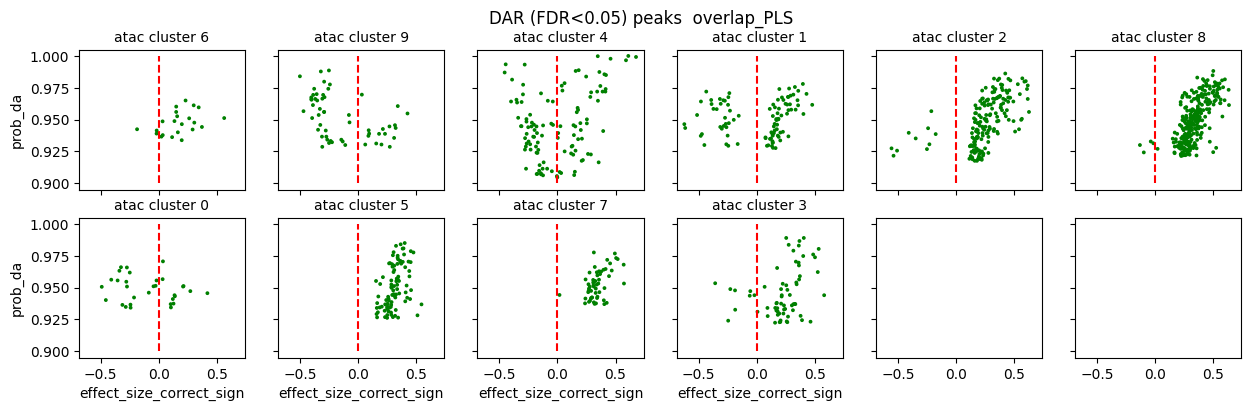

In [67]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'green', False: 'grey'}
show_cat = 'overlap_' + 'PLS'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 3, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

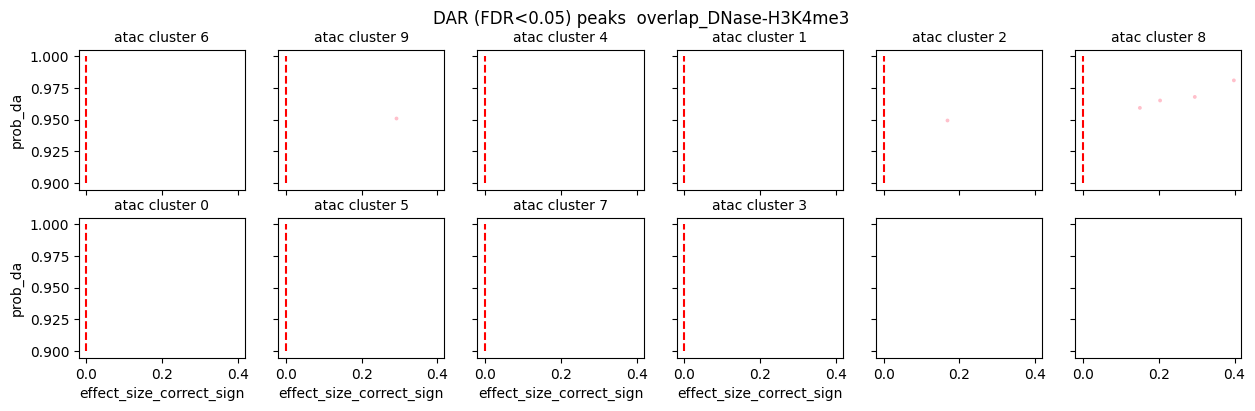

In [68]:
fig, axes = plt.subplots(2, 6,  figsize=(15,4),  sharex=True, sharey=True)
axes = axes.flatten()

color_map = {True: 'pink', False: 'grey'}
show_cat = 'overlap_' + 'DNase-H3K4me3'

for i, cluster in enumerate(cluster_list):
    ax = axes[i]
    plot_df = atac_cluster_DARs[cluster].loc[(atac_cluster_DARs[cluster]['is_da_fdr']) & (atac_cluster_DARs[cluster][show_cat]) ]
    plot_df.plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'atac cluster {cluster}', s = 3, 
                         c = plot_df[show_cat].map(color_map)  )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle(f'DAR (FDR<0.05) peaks  {show_cat}', fontsize=12)
plt.show()

Entropy_peak_cluster: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
median_entropy: [-0.905 -0.736 -0.652 -0.777 -0.881 -0.745 -0.874 -0.753 -0.58  -0.861]
mean_entropy: [-0.916 -0.764 -0.66  -0.794 -0.884 -0.753 -0.888 -0.753 -0.528 -0.83 ]


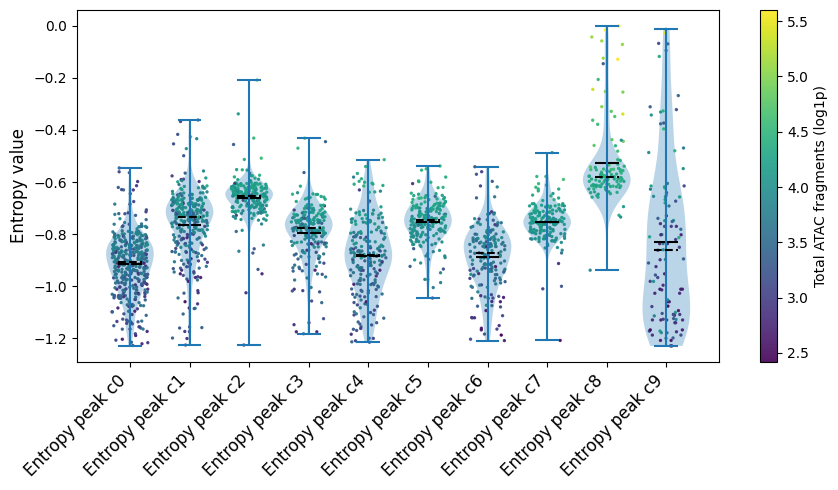

In [44]:
x_positions = range(10)  
widths=0.8
labels = []
    
fig, ax = plt.subplots( figsize=(9, 5))

# Violin plots
entropy_value = [np.log10(h5_atac_entropy_peak_SADE.obs.loc[h5_atac_entropy_peak_SADE.obs['clusters_peakvi_SADE'] == str(c), 'Entropy'].fillna(1)) for c in x_positions]
total_atac_fragments = [h5_atac_entropy_peak_SADE.obs.loc[h5_atac_entropy_peak_SADE.obs['clusters_peakvi_SADE'] == str(c), 'log10_total_frag'] for c in x_positions]
color_range = (h5_atac_entropy_peak_SADE.obs['log10_total_frag'].min(), h5_atac_entropy_peak_SADE.obs['log10_total_frag'].max())
for i, v in enumerate(entropy_value):
    if len(v) ==0:
        entropy_value[i] = np.array([np.inf])  # to avoid error in violin plot when no data point exists
        total_atac_fragments[i] = np.array([np.inf])
        
median_entropy = [np.median(a) for a in entropy_value]
mean_entropy = [np.mean(a) for a in entropy_value]
color_range = (h5_atac_entropy_peak_SADE.obs['log10_total_frag'].min(), h5_atac_entropy_peak_SADE.obs['log10_total_frag'].max())
vp = ax.violinplot( entropy_value, 
              positions=x_positions, widths=widths, vert=True, 
              showmedians=True, showmeans=True)

np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width, color, color_range):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    norm = colors.Normalize(vmin=color_range[0], vmax=color_range[1])
    color_bar = ax.scatter(x_jittered, data_group, c=color, alpha=0.9, s=2, norm=norm) # s controls point size
    return color_bar
  
for i, group_data in enumerate(entropy_value):
    cb = add_jittered_points(ax, group_data, x_positions[i], color=total_atac_fragments[i],color_range=color_range, jitter_width=0.3)


ax.set_xticks(x_positions)
ax.set_xticklabels(['Entropy peak c' + str(c) for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Entropy value', fontsize=12)

cbar = fig.colorbar(cb, ax=ax)
cbar.set_label('Total ATAC fragments (log1p)') # Set the label for the colorbar

vp['cmeans'].set_color('black')
vp['cmedians'].set_color('black')
vp['cmedians'].set_linestyles('dashed')


plt.tight_layout()


print (f'Entropy_peak_cluster: {list(x_positions )}')
print(f'median_entropy: {np.round(median_entropy, 3)}')
print(f'mean_entropy: {np.round(mean_entropy, 3)}')

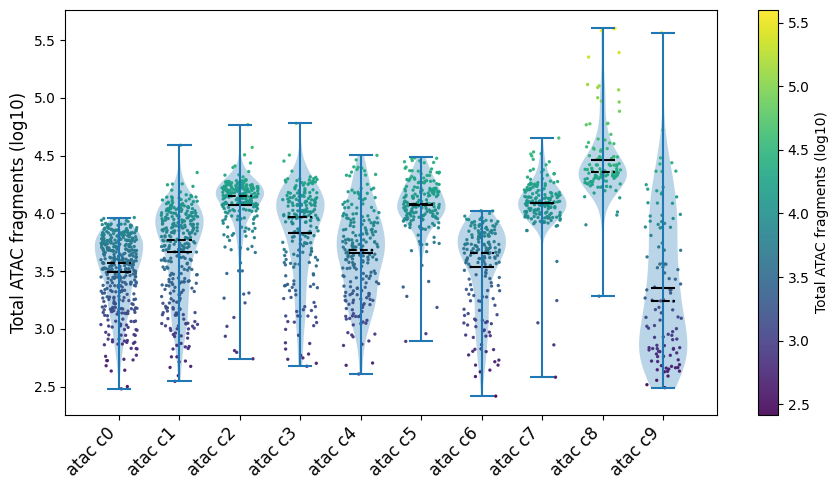

In [51]:
x_positions = range(10)  
widths=0.8
labels = []
    
fig, ax = plt.subplots( figsize=(9, 5))

# Violin plots
total_atac_fragments = [h5_atac_entropy_peak_SADE.obs.loc[h5_atac_entropy_peak_SADE.obs['clusters_peakvi_SADE'] == str(c), 'log10_total_frag'] for c in x_positions]
color_range = (h5_atac_entropy_peak_SADE.obs['log10_total_frag'].min(), h5_atac_entropy_peak_SADE.obs['log10_total_frag'].max())
for i, v in enumerate(entropy_value):
    if len(v) ==0:
        total_atac_fragments[i] = np.array([np.inf])  # to avoid error in violin plot when no data point exists
        

color_range = (h5_atac_entropy_peak_SADE.obs['log10_total_frag'].min(), h5_atac_entropy_peak_SADE.obs['log10_total_frag'].max())
vp = ax.violinplot( total_atac_fragments, 
              positions=x_positions, widths=widths, vert=True, 
              showmedians=True, showmeans=True)

np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width, color, color_range):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    norm = colors.Normalize(vmin=color_range[0], vmax=color_range[1])
    color_bar = ax.scatter(x_jittered, data_group, c=color, alpha=0.9, s=2, norm=norm) # s controls point size
    return color_bar
  
for i, group_data in enumerate(total_atac_fragments):
    cb = add_jittered_points(ax, group_data, x_positions[i], color=total_atac_fragments[i],color_range=color_range, jitter_width=0.3)


ax.set_xticks(x_positions)
ax.set_xticklabels(['atac c' + str(c) for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Total ATAC fragments (log10)', fontsize=12)

cbar = fig.colorbar(cb, ax=ax)
cbar.set_label('Total ATAC fragments (log10)') # Set the label for the colorbar

vp['cmeans'].set_color('black')
vp['cmedians'].set_color('black')
vp['cmedians'].set_linestyles('dashed')


plt.tight_layout()


